In [1]:
# =========================================================
# Add sentiment labels to existing feature-engineered file
# Keeps all 145 original columns, adds: text (alias), sentiment, sentiment_confidence
# =========================================================

# !pip install -q transformers torch

import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

INPUT_PATH = "/content/final_feature_engineered.csv"
OUTPUT_PATH = "/content/final_feature_engineered_with_sentiment.csv"

MODEL_NAME = "ProsusAI/finbert"
TEXT_COLUMN = "Title"   # sentiment is generated from raw title text only

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---- Load full engineered dataset (all 145 columns preserved) ----
df = pd.read_csv(INPUT_PATH)
print(f"Loaded shape: {df.shape}")

# ---- Handle missing/blank titles safely (won't drop rows, just labels them 'unknown') ----
texts = df[TEXT_COLUMN].fillna("").astype(str).str.strip()

# ---- Load pretrained FinBERT ----
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

id2label = model.config.id2label
print(f"FinBERT label mapping: {id2label}")

sentiments = []
confidences = []

BATCH_SIZE = 32
text_list = texts.tolist()

with torch.no_grad():
    for i in tqdm(range(0, len(text_list), BATCH_SIZE)):
        batch = text_list[i:i + BATCH_SIZE]

        # Empty strings get a placeholder to avoid tokenizer errors
        safe_batch = [t if len(t) > 0 else "no title" for t in batch]

        inputs = tokenizer(
            safe_batch, padding=True, truncation=True, max_length=64, return_tensors="pt"
        ).to(device)
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)
        top_probs, top_idx = torch.max(probs, dim=-1)

        sentiments.extend([id2label[int(idx)] for idx in top_idx.cpu().numpy()])
        confidences.extend(top_probs.cpu().numpy().tolist())

# ---- Mark rows that had no real title as "unknown" instead of a false sentiment ----
for i, t in enumerate(text_list):
    if len(t) == 0:
        sentiments[i] = "unknown"
        confidences[i] = 0.0

df["sentiment"] = sentiments
df["sentiment_confidence"] = confidences

# ---- AMENDMENT: add a "text" alias column so the fine-tuning script's ----
# ---- default TEXT_COLUMN = "text" works without any further edits ----
df["text"] = df[TEXT_COLUMN]

print(f"\nFinal shape: {df.shape}")
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved final file to: {OUTPUT_PATH}")

Using device: cuda
Loaded shape: (4999, 145)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

FinBERT label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}


  0%|          | 0/157 [00:00<?, ?it/s]


Final shape: (4999, 148)

Sentiment distribution:
sentiment
neutral     2448
positive    1469
negative    1082
Name: count, dtype: int64

Saved final file to: /content/final_feature_engineered_with_sentiment.csv


In [5]:
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 20.3 MB/s eta 0:00:00


Using device: cuda
GPU: Tesla T4

DATASET OVERVIEW (RAW)
Shape: (4999, 148)

Column names: ['URL', 'Title', 'title_clean', 'domain_freq_encoded', 'domain_afr.com', 'domain_bloomberg.com', 'domain_businesstimes.com.sg', 'domain_cnbc.com', 'domain_finance.yahoo.com', 'domain_financialpost.com', 'domain_marketscreener.com', 'domain_money.usnews.com', 'domain_morningstar.com', 'domain_ndtvprofit.com', 'domain_other', 'domain_seekingalpha.com', 'domain_theaustralian.com.au', 'domain_thecanadianpressnews.ca', 'domain_thehindubusinessline.com', 'domain_tradingview.com', 'url_year', 'url_month', 'url_length', 'url_path_word_count', 'title_char_len', 'title_word_count', 'title_avg_word_len', 'title_digit_count', 'title_has_number', 'title_upper_word_count', 'title_capitalized_word_count', 'title_proper_noun_ratio', 'title_has_dollar', 'title_has_percent', 'title_has_question', 'title_has_exclaim', 'title_has_colon', 'title_punct_count', 'kw_markets', 'kw_business', 'kw_technology', 'kw_politics

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `3`.



Loading model: ProsusAI/finbert


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.974394,0.888973,0.674493,0.682279,0.674493,0.660433
2,0.746515,0.831441,0.685165,0.688161,0.685165,0.682029
3,0.484716,0.935324,0.676628,0.683496,0.676628,0.677625
4,0.337857,1.090343,0.652081,0.656303,0.652081,0.651014
5,0.263358,1.170225,0.662753,0.669437,0.662753,0.661464


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


FINAL EVALUATION - TRAINING SET



Training Accuracy:  0.8417
Training Precision: 0.8448
Training Recall:    0.8417
Training F1-score:  0.8404

FINAL EVALUATION ON TEST SET



Testing Accuracy:  0.6852
Testing Precision: 0.6882
Testing Recall:    0.6852
Testing F1-score:  0.6820

Classification Report (Test Set):
              precision    recall  f1-score   support

    Business       0.71      0.60      0.65       353
      Energy       0.53      0.33      0.41        24
      Health       0.58      0.64      0.61        28
     Markets       0.64      0.77      0.70       286
    Politics       0.74      0.80      0.77       164
  Technology       0.73      0.63      0.68        82

    accuracy                           0.69       937
   macro avg       0.66      0.63      0.64       937
weighted avg       0.69      0.69      0.68       937



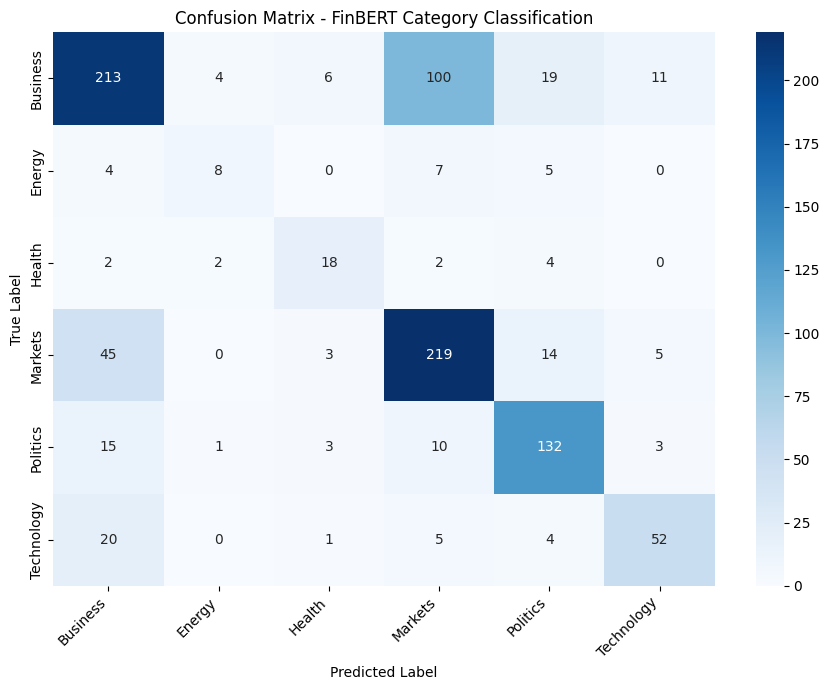

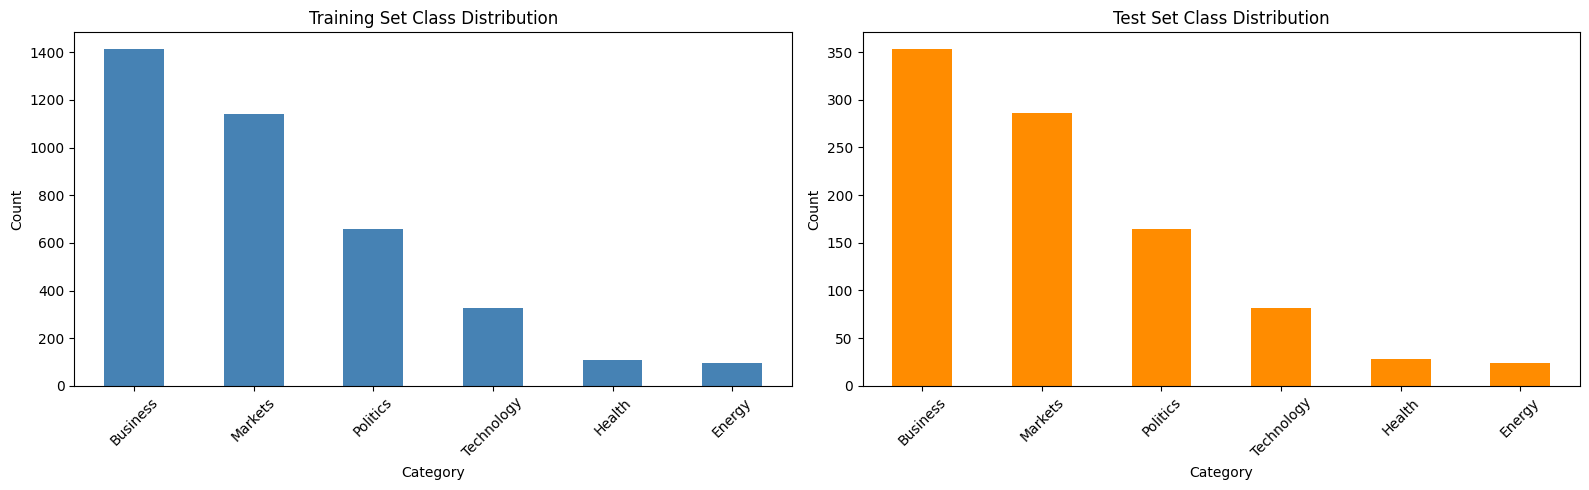

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model and tokenizer saved to: /content/finbert_category_classification_model

FINAL TRAINING SUMMARY
Total articles used (after cleaning): 4683
Number of classes: 6
Class names: ['Business', 'Energy', 'Health', 'Markets', 'Politics', 'Technology']
Training samples: 3746
Testing samples: 937
Model name: ProsusAI/finbert
Epochs (max, early stopping enabled): 15
Max token length: 256
Batch size: 16
Learning rate: 2e-05
Training Accuracy: 0.8417
Testing Accuracy: 0.6852
Model saved to: /content/finbert_category_classification_model


In [3]:
# =========================================================
# FinBERT Fine-Tuning - Topic Classification (Category labels)
# Runs in Google Colab (GPU recommended: Runtime > Change runtime type > GPU)
# =========================================================

# -------------------------
# 0. Install dependencies (recommended: run this first, then restart runtime)
# -------------------------
# !pip install -q -U transformers accelerate datasets scikit-learn torch

import os
import random
import inspect
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

# =========================================================
# 1. CONFIGURATION - EDIT THESE AS NEEDED
# =========================================================

DATASET_PATH = "/content/final_feature_engineered_with_sentiment.csv"

TEXT_COLUMN = "text"        # <-- name of the column containing article text
LABEL_COLUMN = "Category"   # <-- using the ACTUAL/original labels (topic), not sentiment

MODEL_NAME = "ProsusAI/finbert"
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS = 15                   # EXACTLY 15 EPOCHS as required
RANDOM_SEED = 42

SAVE_DIR = "/content/finbert_category_classification_model"

# =========================================================
# 2. REPRODUCIBILITY
# =========================================================

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_all_seeds(RANDOM_SEED)

# =========================================================
# 3. DEVICE SETUP
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# =========================================================
# 4. LOAD DATASET
# =========================================================

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}. "
        f"Please update DATASET_PATH with the correct filename."
    )

df = pd.read_csv(DATASET_PATH)

print("\n" + "=" * 60)
print("DATASET OVERVIEW (RAW)")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")

if LABEL_COLUMN not in df.columns:
    raise KeyError(
        f"LABEL_COLUMN '{LABEL_COLUMN}' not found in dataset columns: {list(df.columns)}. "
        f"Please update LABEL_COLUMN at the top of the script."
    )
if TEXT_COLUMN not in df.columns:
    raise KeyError(
        f"TEXT_COLUMN '{TEXT_COLUMN}' not found in dataset columns: {list(df.columns)}. "
        f"Please update TEXT_COLUMN at the top of the script."
    )

print(f"\nLabel distribution (raw):\n{df[LABEL_COLUMN].value_counts(dropna=False)}")

# =========================================================
# 5. CLEAN DATA
# =========================================================

initial_len = len(df)

# Drop rows with missing text or label
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()

# Ensure text is string type and strip whitespace
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str).str.strip()
df = df[df[TEXT_COLUMN].str.len() > 0].copy()

# Normalize label formatting (strip whitespace only — keep original casing for Category names)
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()
df = df[df[LABEL_COLUMN].str.len() > 0].copy()

# Drop exact duplicate rows
df = df.drop_duplicates(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)

cleaned_len = len(df)
print(f"\nRows removed during cleaning: {initial_len - cleaned_len}")
print(f"Remaining rows after cleaning: {cleaned_len}")

if cleaned_len == 0:
    raise ValueError("No data remaining after cleaning. Check your dataset and column names.")

print(f"\nLabel distribution (cleaned):\n{df[LABEL_COLUMN].value_counts()}")

# =========================================================
# 6. ENCODE LABELS
# =========================================================

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df[LABEL_COLUMN])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(f"\nDetected classes ({num_classes}): {class_names}")
print("Label mapping:")
for idx, name in enumerate(class_names):
    print(f"  {idx} -> {name}")

if num_classes < 2:
    raise ValueError(
        f"Only {num_classes} class found in labels. Need at least 2 classes for classification."
    )

# Warn about very rare classes (can break stratified split)
class_counts = df["label_encoded"].value_counts()
rare_classes = class_counts[class_counts < 2]
if len(rare_classes) > 0:
    print(f"\nWARNING: classes with fewer than 2 samples will be dropped (can't stratify): {rare_classes.index.tolist()}")
    df = df[~df["label_encoded"].isin(rare_classes.index)].copy()
    label_encoder = LabelEncoder()
    df["label_encoded"] = label_encoder.fit_transform(df[LABEL_COLUMN])
    class_names = list(label_encoder.classes_)
    num_classes = len(class_names)
    print(f"Classes after dropping rare ones ({num_classes}): {class_names}")

# =========================================================
# 7. TRAIN / TEST SPLIT (80/20, stratified)
# =========================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df["label_encoded"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nTraining samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# =========================================================
# 8. TOKENIZER
# =========================================================

print(f"\nLoading tokenizer for: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# =========================================================
# 9. PYTORCH DATASET CLASS
# =========================================================

class FinancialTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item


train_dataset = FinancialTextDataset(
    train_df[TEXT_COLUMN].values,
    train_df["label_encoded"].values,
    tokenizer,
    MAX_LENGTH,
)

test_dataset = FinancialTextDataset(
    test_df[TEXT_COLUMN].values,
    test_df["label_encoded"].values,
    tokenizer,
    MAX_LENGTH,
)

# =========================================================
# 10. LOAD MODEL
# =========================================================

print(f"\nLoading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    ignore_mismatched_sizes=True,  # FinBERT's default head (3 classes) differs from our Category count
)
model.to(device)

# =========================================================
# 11. METRICS FUNCTION FOR TRAINER
# =========================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# =========================================================
# 12. TRAINING ARGUMENTS (version-safe across transformers releases)
# =========================================================

ta_params = inspect.signature(TrainingArguments.__init__).parameters
strategy_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

training_args_kwargs = {
    "output_dir": "/content/finbert_category_checkpoints",
    "num_train_epochs": NUM_EPOCHS,          # EXACTLY 15 EPOCHS
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    strategy_key: "epoch",
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "logging_steps": 50,
    "save_total_limit": 2,
    "seed": RANDOM_SEED,
    "fp16": torch.cuda.is_available(),
    "report_to": "none",
}

if "logging_dir" in ta_params:
    training_args_kwargs["logging_dir"] = "/content/finbert_category_logs"

training_args = TrainingArguments(**training_args_kwargs)

# =========================================================
# 13. TRAINER (ADDED: EarlyStoppingCallback)
# =========================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],  # stop if no F1 improvement for 3 epochs
)

# =========================================================
# 14. TRAIN
# =========================================================

print("\n" + "=" * 60)
print(f"STARTING TRAINING FOR UP TO {NUM_EPOCHS} EPOCHS (early stopping enabled)")
print("=" * 60)

trainer.train()

# =========================================================
# 15. FINAL EVALUATION (ADDED: training accuracy alongside testing accuracy)
# =========================================================

print("\n" + "=" * 60)
print("FINAL EVALUATION - TRAINING SET")
print("=" * 60)

train_predictions_output = trainer.predict(train_dataset)
train_logits = train_predictions_output.predictions
train_true = train_predictions_output.label_ids
train_pred = np.argmax(train_logits, axis=-1)

train_accuracy = accuracy_score(train_true, train_pred)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
    train_true, train_pred, average="weighted", zero_division=0
)

print(f"\nTraining Accuracy:  {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall:    {train_recall:.4f}")
print(f"Training F1-score:  {train_f1:.4f}")

print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=-1)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"\nTesting Accuracy:  {accuracy:.4f}")
print(f"Testing Precision: {precision:.4f}")
print(f"Testing Recall:    {recall:.4f}")
print(f"Testing F1-score:  {f1:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# =========================================================
# 16. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FinBERT Category Classification")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# =========================================================
# 17. CLASS DISTRIBUTION PLOTS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

train_df[LABEL_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Training Set Class Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

test_df[LABEL_COLUMN].value_counts().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# =========================================================
# 18. SAVE MODEL AND TOKENIZER
# =========================================================

os.makedirs(SAVE_DIR, exist_ok=True)
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"\nModel and tokenizer saved to: {SAVE_DIR}")

# =========================================================
# 19. PREDICTION FUNCTION FOR NEW ARTICLES
# =========================================================

def predict_category(text: str, model_dir: str = SAVE_DIR, max_length: int = MAX_LENGTH):
    """
    Predict the category/topic of a new financial article headline.
    Returns predicted category + per-class confidence.
    """
    infer_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    infer_tokenizer = AutoTokenizer.from_pretrained(model_dir)
    infer_model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    infer_model.to(infer_device)
    infer_model.eval()

    inputs = infer_tokenizer(
        str(text),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    ).to(infer_device)

    with torch.no_grad():
        outputs = infer_model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    predicted_idx = int(np.argmax(probs))
    predicted_label = label_encoder.inverse_transform([predicted_idx])[0]

    class_probabilities = {
        class_names[i]: float(probs[i]) for i in range(len(class_names))
    }

    return {
        "predicted_category": predicted_label,
        "confidence": float(probs[predicted_idx]),
        "class_probabilities": class_probabilities,
    }


# Example usage (uncomment to test):
# example_text = "3 Robotics Stocks to Buy in October"
# result = predict_category(example_text)
# print(result)

# =========================================================
# 20. FINAL TRAINING SUMMARY (ADDED: training + testing accuracy)
# =========================================================

print("\n" + "=" * 60)
print("FINAL TRAINING SUMMARY")
print("=" * 60)
print(f"Total articles used (after cleaning): {cleaned_len}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")
print(f"Model name: {MODEL_NAME}")
print(f"Epochs (max, early stopping enabled): {NUM_EPOCHS}")
print(f"Max token length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")
print(f"Model saved to: {SAVE_DIR}")
print("=" * 60)